---
title: Unsupervised Learning
jupyter: python3
execute:
  cache: true
---

## Introduction

Suppose that we have a set of $N$ observations $(x_1, x_2, \ldots, x_N)$ of a
random $p$-vector $X$. The goal in unsupervised learning is to infer properties
of the probability density of $X$. Note the primary difference with supervised
learning (@sec-08-top). In that context, we will have a set of labels
$y_1,\ldots, y_N$ in addition to the $x_i$'s. Here, we do not have labelled
data.

In situations where $p \le 3$, then graphical methods and numerical summaries
such as correlations will suffice to help us understand the structure of the
data. However, these methods breakdown as soon as $p$ increases beyond 3. This
topic introduces techniques that we can use, even when $p$ is large, to :

1.  Understand and interpret the main sources of variation in the data,
2.  Identify "groups" or clusters within the data for further study.
3.  Visualise high-dimensional data

In the code below, one of the modules imported is `clust`. It contains a
function that we shall use in the section on clustering (@sec-07-clustering).

In [1]:
import pandas as pd
import numpy as np
from scipy.cluster import hierarchy

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from itables import show
from pprint import pprint

import folium
import geopandas

from sklearn import decomposition, preprocessing
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS, TSNE
from sklearn.ensemble import IsolationForest

from sentence_transformers import SentenceTransformer

from ind5003 import clust

::: {#exm-wine-quality-1 style="background-color: #D5D1D164; padding: 20px"}

### Wine quality data
\index{Wine quality!Description}

The UCI Machine Learning Repository contains a 
[dataset on Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality). 
It consists of two tables - one corresponding to white wine and one
corresponding to red wine. Each table contains the following columns:

1.  fixed acidity
2.  volatile acidity
3.  citric acid
4.  residual sugar
5.  chlorides
6.  free sulfur dioxide
7.  total sulfur dioxide
8.  density
9.  pH
10. sulphates
11. alcohol
12. quality (score between 0 and 10)

Columns 1 - 11 are numeric variables, measured objectively on the wines. Column
12 is a subjective evaluation made by wine experts, based on sensory data. Each
quality score is the median of at least 3 evaluations. Although this dataset was
created for a supervised learning problem, we shall use it to practice
unsupervised learning techniques. To do so, we shall ignore the column
corresponding to quality in most sections until the end, when we try to
interpret the findings.

Our first step is to read in the two tables and combine them into one.

In [2]:
wine_red = pd.read_csv("data/wine+quality/winequality-red.csv", 
                       delimiter=";" )
wine_red['type'] = "red"
wine_white = pd.read_csv("data/wine+quality/winequality-white.csv", 
                         delimiter=";")
wine_white['type'] = "white"

# remove spaces in column names:
col_names = ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
             'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide',
             'density', 'pH', 'sulphates', 'alcohol', 'quality', 'type']
wine2 = pd.concat([wine_red, wine_white], ignore_index=True)
wine2.columns = col_names

At the end of the code chunk above, the DataFrame `wine2` contains both the red
and white wine data. The column names have also been edited to remove
whitespaces. Here is a brief overview of the data.

::: {.content-visible when-format="html"}

In [3]:
show(wine2.head(20))

Loading ITables v2.8.0 from the internet... (need help?)


:::

::: {.content-visible when-format="pdf"}

In [4]:
print(wine2.head())

   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality type  
0      9.4        5  red  
1      9.8        5  red  
2    

:::

:::

## Principal Components Analysis

A Principal Components Analysis (PCA) explains the covariance matrix of a set of
variables through a few *linear combinations* of these variables. The general
objectives are

1. data reduction into features that are uncorrelated with one another,
2. interpretation, and
3. visualisation.

### Formal Set-up

Suppose that we have $N$ observations of a random vector of length $p$. We can
represent these values in a matrix with $N$ rows and $p$ columns:

$$
\mathbf{X}_{N\times p} = 
\begin{bmatrix}
x_{1,1} & x_{1,2} & \ldots & x_{1,p}\\
\cdots & \cdots & \cdots & \cdots \\
x_{N,1} & x_{N,2} & \ldots & x_{N,p}
\end{bmatrix}
$$

Let $\mathbf{x}_j = \begin{bmatrix} x_{1,j} & x_{2,j} & \cdots & x_{N,j} \end{bmatrix}^T$ 
correspond to column $j$ in $\mathbf{X}$, for $j=1,\ldots,p$. We represent the
mean of column $j$ with

$$
\bar{x}_j = \frac{1}{N} \sum_{i=1}^N x_{i,j}
$$

The first step in a PCA is to compute the covariance matrix of the data:

$$
S_{p\times p} = 
\begin{bmatrix}
s^2_1 & s^2_{1,2} & \ldots & s^2_{1,p}\\
\cdots & \cdots & \cdots & \cdots \\
s^2_{p,1} & s^2_{p,2} & \ldots & s^2_p
\end{bmatrix}
$$


where 
$s^2_{m,n} = \frac{1}{N-1} \sum_{k=1}^N (x_{k,m} - \bar{x}_m)(x_{k,n} - \bar{x}_n)$ 
is the sample covariance between columns $m$ and $n$ of matrix $X$,
where $1 < m,n < p$. A PCA analysis yields coefficients $a_i$ such that:

$$
\mathbf{y}_i = a_{i,1} \mathbf{x}_1 + a_{i,2} \mathbf{x}_2 + \cdots + a_{i,p} \mathbf{x}_p, \quad i = 1,\ldots,p
$$

In other words, $\mathbf{y}_i$ is a column vector of length $N$, formed from a
linear combinations of the columns in the original $\mathbf{X}$ matrix. Each
$\mathbf{y}_i$ is what we refer to as a principal component. From a symmetric 
$p \times p$ matrix, we can always compute $p$ principal components, and these
vectors will be uncorrelated with each other. 

::: {.callout-note}

However this does not help us! We have not achieved any reduction!?    

:::

The value of PCA comes from the possibility that the *first few* principal
components usually explain most of the variability in the data ($\sum_i^p
s^2_i$). The last few principal components typically explain little of the
variability in the data. Indeed, there is some loss of information when we drop
them, but the benefit is that we can (hopefully) focus on much fewer dimensions
than the original $p$ (which could be in the hundreds, even). Moreover, as these
components will be uncorrelated by design, they can be used as features to solve
any issues of multicollinearity in our data.

::: {#exm-wine-quality-2 style="background-color: #D5D1D164; padding: 20px"}
### PCA on wine dataset
\index{Wine quality!PCA}

While it is possible to extract principal components using either the covariance
matrix or the correlation matrix, using the latter avoids situations where the
primary principal component is simply driven by the scale of one or more columns
in the original dataset. Here, we scale the first 11 columns (exclude quality
and type) so that each column has mean 0 and variance 1.

In [3]:
X_raw = wine2.iloc[:, :-2]
scaler = preprocessing.StandardScaler().fit(X_raw)
X_scaled = scaler.transform(X_raw)

At this point, the `scaler` object contains all the information needed to
scale a dataset, using the column means and standard deviations computed from 
`X_raw`.

It is theoretically possible to extract 11 components from this $X$ matrix. Let
us proceed with that, and assess how many we should keep using a *scree* plot.

In [5]:
pca_full = decomposition.PCA(n_components=11)
pca_full.fit(X_scaled);

A scree plots the variance explained by each subsequent principal component (on
the $y$-axis) versus the order of the principal component. It indicates how much
more value there is in including the subsequent principal component. Generally,
we look for an "elbow" shape to inform us of how many to keep. From below, we
would probably want to retain 4 or 5 principal components.

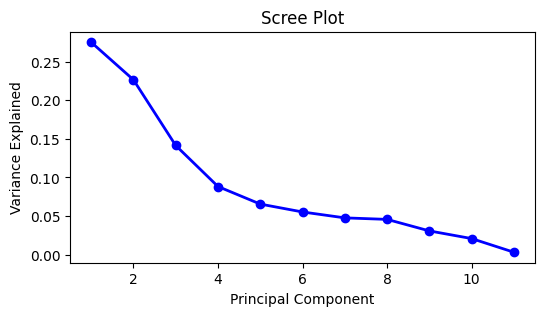

In [7]:
#| fig-cap: Scree plot

PC_values = np.arange(pca_full.n_components_) + 1
plt.figure(figsize=(6,3))
plt.plot(PC_values, pca_full.explained_variance_ratio_, 'o-', linewidth=2,
	color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained');

To find the amount of total variance explained, we can use the following command:

In [8]:
pca_full.explained_variance_ratio_.cumsum()

array([0.2754426 , 0.50215406, 0.64364015, 0.73187216, 0.79731533,
       0.85252548, 0.90008537, 0.94567722, 0.97631577, 0.99701538,
       1.        ])

<br>

With `scikit-learn`, estimated parameters will be accessible through attributes
that end in an underscore. Above, we can see that the first principal component
explains 27.5% of the total variation. The first two componetns explain 50.2% of
the variation, and so on.

It appears that 5 components are enough to explain 79.7% of the variance. Let us
try to take a look at the $a_{i,j}$ coefficients matrix to interpret the
principal components. This set of coefficients is also known as the loadings
matrix.

In [9]:
pca = decomposition.PCA(n_components=5)
pca.fit(X_scaled)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loading_matrix = pd.DataFrame(loadings, 
                              columns=['PC' + str(x+1) for x in range(0, 5)], 
                              index=col_names[:-2])

In social sciences especially, it is a convention to drop loadings that are
smaller than 0.3 in absolute value and then to interpret the remaining
coefficients as well as possible.

In [10]:
loading_matrix2 = loading_matrix.copy()
loading_matrix2[loading_matrix.abs()  < 0.300] = 0.00

::: {.content-visible when-format="html"}

In [11]:
#| echo: false
loading_matrix2.round(3).style.background_gradient(cmap='coolwarm_r', 
                                                   vmin=-1, vmax=1)

,PC1,PC2,PC3,PC4,PC5
fixed_acidity,-0.416000,0.531000,0.542000,0.000000,0.000000
volatile_acidity,-0.663000,0.000000,-0.383000,0.000000,0.000000
citric_acid,0.000000,0.000000,0.737000,0.000000,0.000000
residual_sugar,0.602000,0.521000,0.000000,0.000000,0.000000
chlorides,-0.505000,0.498000,0.000000,0.000000,0.521000
free_sulfur_dioxide,0.750000,0.000000,0.000000,0.352000,0.000000
total_sulfur_dioxide,0.848000,0.000000,0.000000,0.000000,0.000000
density,0.000000,0.922000,0.000000,0.000000,0.000000
pH,-0.381000,0.000000,-0.568000,0.408000,-0.385000
sulphates,-0.512000,0.303000,0.000000,0.631000,0.000000


:::

::: {.content-visible when-format="pdf"}

In [13]:
#| echo: false
loading_matrix2.round(2)

,PC1,PC2,PC3,PC4,PC5
fixed_acidity,-0.42,0.53,0.54,0.00,0.00
volatile_acidity,-0.66,0.00,-0.38,0.00,0.00
citric_acid,0.00,0.00,0.74,0.00,0.00
residual_sugar,0.60,0.52,0.00,0.00,0.00
chlorides,-0.51,0.50,0.00,0.00,0.52
free_sulfur_dioxide,0.75,0.00,0.00,0.35,0.00
total_sulfur_dioxide,0.85,0.00,0.00,0.00,0.00
density,0.00,0.92,0.00,0.00,0.00
pH,-0.38,0.00,-0.57,0.41,-0.38
sulphates,-0.51,0.30,0.00,0.63,0.00


:::

From above, if we focus on the top two principal components, we could interpret them as:

1. A combination of sugar and sulphur dioxides contrasted against acidity,
   chlorides and sulphates.
2. A contrast between density and alcohol.

In the following code, we **apply** the transformation to obtain the actual
principal components ($\mathbf{y}_j$'s).

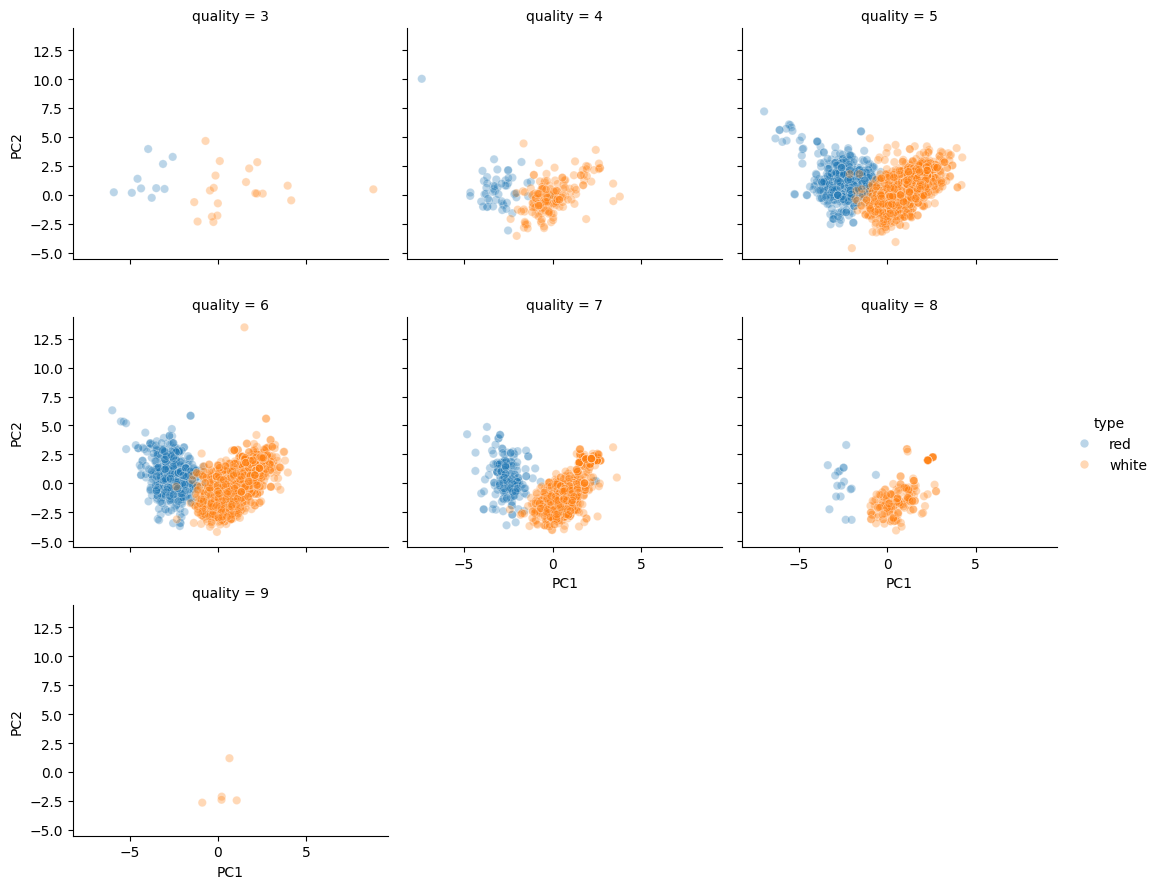

In [14]:
#| fig-align: center

X_transformed = pca.transform(X_scaled)
X_transformed_df = pd.DataFrame(X_transformed, 
                                columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])
X_transformed_df[['quality', 'type']] = wine2[['quality', 'type']]

sns.relplot(data=X_transformed_df, x='PC1', y='PC2', col='quality', col_wrap= 3, 
            hue='type', marker='o', alpha=0.3, height=3, aspect=1.2);

Judging from the plots, red wines tend to be lower on PC1. Can we tie this back
to the columns in the data to understand the difference between white and red
wines more?

For white wines, there seems to be a linear relation between PC1 and PC2.
However, for red wines, the range of PC1 values is quite narrow, and the PC1
values do not appear to suggest what the PC2 values could be.

Finally, neither PC1 nor PC2 appears to provide a clue on the the subjective
quality of the wine.

:::

## Clustering {#sec-07-clustering}

In the previous section, the goal was to reduce the dimensionality of the
dataset. In this section, our goal is to segment the data. By assigning
individual observations into groups (or clusters) such that those within each
group are "closely related", we can gain an understanding of our data at a
higher level.

There are many different clustering algorithms. You may have heard of K-means, a
very popular one before. The one we are going to use here is very similar to it.
It is known as **agglomerative hierarchical clustering**. Let's take a look at
how it works first.

### Hierarchical Clustering

#### Dissimilarity Measures Between Individual Observations

As we mentioned earlier, cluster analysis tries to identify groups such that
those within a group are "similar" to one another. In order to proceed, we need to
formalise this idea of similarity/dissimilarity.

As before, suppose that we have $N$ observations $x_1, x_2, x_3,\ldots,x_N$ and
we wish to group them into $K$ clusters. Each observation is typically a vector
of $p$ observations, so we may write $x_i = (x_{i,1}, x_{i,2}, \ldots, x_{i,p})$.

Most clustering algorithms require a dissimilarity matrix as input, so we need
function that can measure **pairwise dissimilarity**. One of the most common
choices is the Euclidean distance (or rather the $L_2$-norm) between $x_i$ and
$x_j$:

\begin{equation*}
d(x_i,\;x_j) = \sqrt{  \sum_{s=1}^p (x_{i,s} - x_{j,s})^2 }
\end{equation*}

Another common choice is the $L_1$-norm:

\begin{equation*}
d(x_i,\;x_j) = \sum_{s=1}^p |x_{i,s} - x_{j,s}|
\end{equation*}

#### Dissimilarity Measures Between Clusters or Groups

For hierarchical clustering, we need to build on this choice of pairwise
dissimilarity to obtain a measure of dissimilarity between groups. In other
words, suppose we have two groups of points $G$ and $H$, with $N_G$ and $N_H$
points within them respectively. We wish to use the pairwise dissimilarity
between points in $G$ and $H$, to compute a dissimilarity between $G$ and $H$.
We call this the **linkage method**, and there are several options for this too:

1. Single linkage takes the intergroup dissimilarity to be that of the closest
   (least dissimilar) pair.
\begin{equation*}
d_S(G,H) = \min_{i \in G, j \in H} d(x_i,\, x_j)
\end{equation*}
2. Complete linkage takes the intergroup dissimilarity to be that of the
   furthest (most dissimilar) pair.
\begin{equation*}
d_C(G,H) = \max_{i \in G, j \in H} d(x_i,\, x_j)
\end{equation*}
3. Average linkage utilises the average of all pairwise dissimilarities between
   the groups:
\begin{equation*}
d_A(G,H) = \frac{1}{N_G N_H} \sum_{i \in G} \sum_{j \in H} d(x_i,x_j)
\end{equation*}
4. Ward linkage uses a more complicated distance to minimise the variance within
   groups. It usually returns more compact clusters than the others. Suppose that
   group $G$ was formed by merging groups $G_1$ and $G_2$. Then the Ward distance
   between groups is
\begin{equation*}
d_W(G,H) = \sqrt{\frac{|H| + |G_1|}{N_G + N_H}d_W(H,G_1)^2 + \frac{|H| + |G_2|}{N_G + N_H}d_W(H,G_2)^2 + \frac{H}{N_G +N_H}d_W(G_1,G_2)^2}
\end{equation*}

The choice of linkage can affect the final clusters we obtain, so it is
important to choose carefully based on the subject matter. Here is a plot from
sklearn, demonstrating the impact of the linkage on the clusters in toy
datasets.

![sklearn documentation](figs/sklearn_linkage_comparison_001.png){width=80%}

#### Agglomerative Hierarchical Clustering Algorithm

The output of the algorithm is a hierarchical representation of the data, where
clusters at each level of the hierarchy are created by merging clusters at the
next lower level. At the lowest level, each cluster contains a single
observation. At the highest level there is only one cluster containing all of
the data.

Starting at the bottom (with $N$ clusters of singletons), we recursively merge a
selected pair of clusters into a single cluster. This produces a grouping at the
next higher level with one less cluster. The pair chosen for merging consist of
the two groups with the smallest intergroup dissimilarity.

As you can tell, this algorithm does not require the number of clusters as an
input. The final number of clusters can be based on a visualisation of this
hierarchy of clusterings, through a dendrogram.

Consider the following set of three points:

In [15]:
#| echo: false
X = np.array([[.25,.7], [.3, .8], [.7, .6]])
X

array([[0.25, 0.7 ],
       [0.3 , 0.8 ],
       [0.7 , 0.6 ]])

Their pairwise distances are:

In [16]:
#| echo: false
pairwise_distances(X).round(3)

array([[0.   , 0.112, 0.461],
       [0.112, 0.   , 0.447],
       [0.461, 0.447, 0.   ]])

In other words, the distance between $x_1$ and $x_2$ is 0.112, between $x_1$ and 
$x_3$ is 0.461, and so on. Hierarchical clustering on this toy dataset would
proceed as in the stages in @fig-toy-clustering.

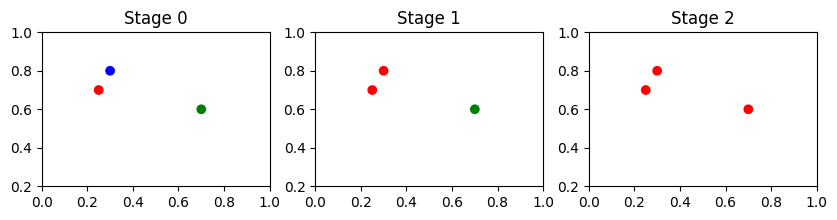

In [17]:
#| fig-align: center
#| fig-cap: "Clustering toy example"
#| label: fig-toy-clustering
#| echo: false
fc_dict={'Stage 0': ['red', 'blue', 'green'], 'Stage 1':['red', 'red', 'green'], 
        'Stage 2':['red']*3}

plt.figure(figsize=(10, 2))
for x,y in enumerate(fc_dict.items()):
    plt.subplot(1,3,x+1);
    plt.scatter(X[:,0], X[:,1], facecolor=y[1]);
    plt.ylim(0.2,1); plt.xlim(0,1);
    plt.title(y[0]);

As we can see the number of clusters changed from 3 to 2 and then to 1. Here is
how we can visualise the hierarchy:

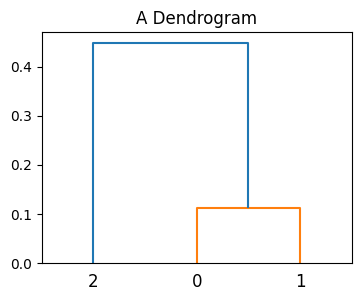

In [18]:
#| fig-align: center

lm0 = hierarchy.linkage(X)
plt.figure(figsize=(4, 3))
hierarchy.dendrogram(lm0,p=2)
plt.title('A Dendrogram');

The dendrogram shows that points with index 0 and 1 (the closest two points)
merge at a small vertical distance (height of green lines), but the group
containing them merges with point 2 at a much higher vertical distance (blue
line on the left). This shows that points 0 and 1 are less dissimilar to one
another than they are (as a group) to point 2. In other words, the 
*height of each node is proportional to the value of the intergroup dissimilarity between its two child nodes*.

::: {#exm-wine-quality-2 style="background-color: #D5D1D164; padding: 20px"}

### Hierarchical clustering of wine 
\index{Wine quality!Hierarchical clustering}

Now we apply this technique to the scaled wine dataset.

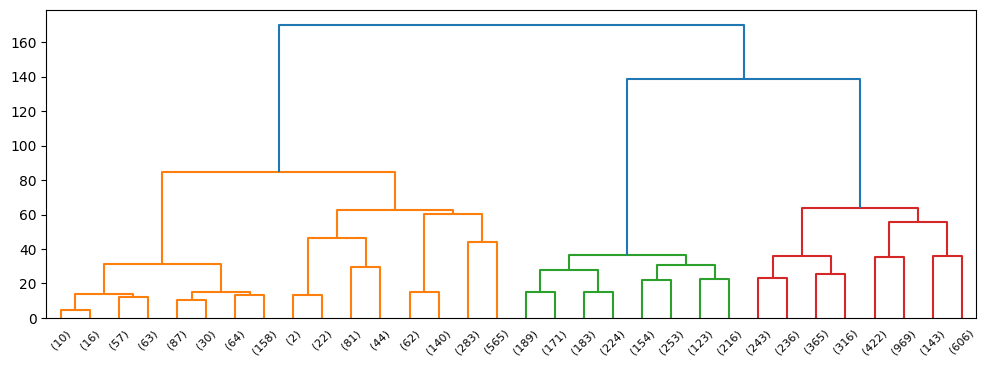

In [19]:
#| fig-align: center
hc1 = hierarchy.linkage(X_transformed_df.iloc[:, :-2], method='ward')

plt.figure(figsize=(12,4))
hierarchy.dendrogram(hc1, p=4, truncate_mode='level');

:::

From the dendrogram alone, it appears plausible that we can break the original
set of data points into two, maybe 3, groups.

::: {.callout-note}

Can we come up with a formal method of determining the optimal number of clusters?    

:::

### Determining the optimal number of clusters

The Silhouette coefficient summarises the within similarity to the between
similarity using the following formula:

\begin{equation*}
S = \frac{b-a}{\max(a,b)}
\end{equation*}

where $b$ is the average distance between an observation and a cluster that it
is not a part of. On the other hand, $a$ is the mean distance within a cluster.
This coefficient takes values between -1 and 1, with values closer to 1
indicating a more optimal clustering.

::: {#exm-wine-quality-3 style="background-color: #D5D1D164; padding: 20px"}

### Wine clustering quality
\index{Wine quality!Silhouette}

Here are the silhouette scores from the two clusterings of the wine data.

In [20]:
out = hierarchy.cut_tree(hc1, n_clusters=3).ravel() 
X_transformed_df['groups'] = out
clust.compute_silhouette_scores(hc1, X_transformed_df.iloc[:, :-2], [2,3,4])

Computing groupings for k=2
Computing score for k=2
Computing groupings for k=3
Computing score for k=3
Computing groupings for k=4
Computing score for k=4


[0.2988729940347066, 0.2549456216980739, 0.24461426523186675]

The silhouette coefficient values we are obtaining are not very good. However,
out of the possible values we tried, $K=2$ seems to be the best.

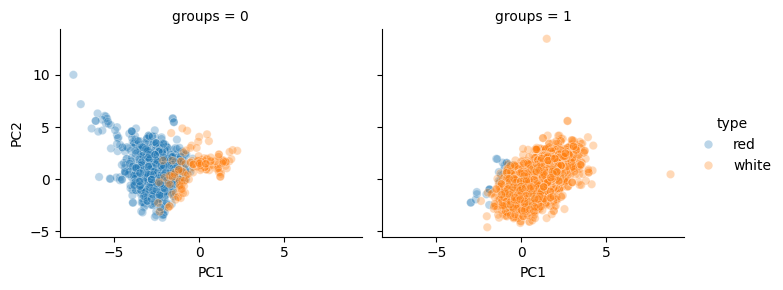

In [21]:
#| fig-align: center
out = hierarchy.cut_tree(hc1, n_clusters=2).ravel() 
X_transformed_df['groups'] = out

sns.relplot(data=X_transformed_df, x='PC1', y='PC2', col='groups', 
            hue='type', marker='o', alpha=0.3, height=3, aspect=1.2);

As we can see, the groupings closely mirror the type of wine (red or white).

In [22]:
wine2.type.groupby(X_transformed_df.groups).describe()

,count,unique,top,freq
groups,,,,
0,1684,2,red,1549
1,4813,2,white,4763


However, notice that there are a number of white wines grouped as 0 (with most
of the other reds). It would be interesting to study what qualities of these
wines led to them being grouped with the reds.

Also, consider what value the PCA brought to this problem. Go back and re-run
the clustering algorithm with the scaled but untransformed data. Does the
quality of clustering differ?

:::

## Outlier Detection

One efficient way of performing outlier detection in high-dimensional datasets
is to use random forests. The `ensemble.IsolationForest` object in
`scikit-learn` "isolates" observations by:

1. Randomly selecting features, and then randomly selecting a split value
   between the maximum and minimum values of the selected feature to form a
   decision tree (see @sec-08-dec-tree).
   * In each tree, the number of splittings required to isolate a sample is equivalent 
     to the path length from the root node to the terminating node.
3. Repeating step 1 to create a forest of trees (see @sec-08-forest).
   
For each observation, the average path length, over the forest of random trees,
is a measure of how anomalous it is. Random partitioning produces noticeably
shorter paths for anomalies. Hence, when a forest of random trees collectively
produce shorter path lengths for particular samples, they are highly likely to
be anomalies.

::: {#exm-taiwan-isol-1 style="background-color: #D5D1D164; padding: 20px"}

### Isolation forest with taiwan dataset
\index{Taiwan Data!Isolation forest}

Let us apply this technique to the Taiwan real estate dataset from the
regression topic. We shall see much more of this dataset in @sec-05-top.

In [23]:
re2 = pd.read_csv("data/taiwan_dataset.csv")
X_re = re2.loc[:, ['trans_date', 'house_age', 'dist_MRT', 'num_stores', 
                   'Xs', 'Ys', 'price']]
X_re_scaled = preprocessing.StandardScaler().fit_transform(X_re)

After reading in and scaling the data, we fit the `IsolationForest` estimator.

In [24]:
clf = IsolationForest(max_samples=300, max_features=2, contamination=0.01, 
                      random_state=503)
clf.fit(X_re_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",300
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",2
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",503
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


Here is a brief explanation of the arguments in the call to `IsolationForest`:

* `contamination` factor is the proportion of outliers that we expect to see in
  the dataset.
* `max_features` corresponds to the number of features to be drawn for *each*
  base estimator
* `max_samples` is the number of samples (observations) to draw from the
  original dataset for each base estimator.

In [25]:
id_outliers = pd.Series(clf.predict(X_re_scaled))
id_outliers.value_counts()

 1    409
-1      5
Name: count, dtype: int64

There are 5 points that have been identified as outliers (coded as -1). As
analysts, we should do our best to understand what property, or combination of
features, led to this.

In [26]:
re2['outliers'] = id_outliers

::: {.content-visible when-format="html"}

In [27]:
show(re2[['house_age', 'dist_MRT', 'num_stores', 'price', 
          'Xs', 'Ys']].groupby(re2.outliers).describe().T)

Loading ITables v2.8.0 from the internet... (need help?)


:::

::: {.content-visible when-format="pdf"}

In [28]:
#| echo: false

tmp_df = re2[['house_age', 'dist_MRT', 'num_stores', 'price', 
		'Xs', 'Ys']].groupby(re2.outliers).describe().T
tmp_df.xs("mean", level=1).round(3)

outliers,-1,1
house_age,25.900,17.612
dist_MRT,6042.907,1023.262
num_stores,1.000,4.132
price,14.920,38.262
Xs,-5.424,0.066
Ys,-1.982,0.024


:::

We can see that the outliers are very different from the remaining points: the
distance to MRT, X-coordinates, and price are all very different. Having
identified these points, our job as analysts is to interpret the differences.


:::

::: {.callout-note}

If we drop the location parameters, would different points be identified as
outliers?

:::

## Visualisation

### MDS

Multidimensional Scaling is a technique for visualising high-dimensional
data. Just like in hierarchical clustering, we begin with a
square matrix consisting of all pairwise dissimilarities $d(x_i,x_j)$ between
our $N$ high-dimensional vectors. With a choice of $k$, we seek
values $z_1, z_2, \ldots, z_N \in \mathbb{R}^k$ such that the following function
is minimised:

$$
S(z_1,\ldots,z_N) = \left[ \sum_{i \ne j} \left( d(x_i,x_j) - ||z_i -
z_j||\right)^2 \right]^{1/2}
$$

Thus the goal of MDS is to find a lower dimensional set of vectors whose
pairwise Euclidean distances are as close as possible to the dissimilarity
matrix of the original vectors.

MDS is *not* the same as Principal Component Analysis (PCA):

* PCA maximises **variance**, orthogonal to earlier components.
* Principal components are ordered; MDS are not.
* Principal components are linear combinations of the original vectors; MDS output is not.

::: {#exm-disease-mds-1 style="background-color: #D5D1D164; padding: 20px"}
### MDS on disease symptoms
\index{Disease Symptoms!Description}

The dataset `disease.csv` contains a list of symptoms that were reported for a
set diseases. Each row in the dataframe corresponds to a particular disease,
while each binary column indicates whether that particular symptom was
frequently present for this disease.

In [29]:
disease = pd.read_csv("data/disease.csv")

::: {.content-visible when-format="html"}

In [30]:
show(disease)

Loading ITables v2.8.0 from the internet... (need help?)


:::

:::

Our goal is to visualise the 41 diseases - diseases with "similar" symptoms
should be plotted "close" to one another. However, the data begets the natural
question: How can we define dissimilarity between the symptom lists of two
diseases?

For this purpose, we shall use the Jaccard similarity index. For two disease
symptom sets $A$ and $B$, the Jaccard dissimilarity is defined to be

$$
J = 1 - \frac{|A \cap B |}{|A \cup B|}
$$

If there are no common symptoms between the two diseases, then the intersection
between the two sets would be the empty set. In that situation, $J$ would take
on the maximum value of 1. If the two symptom lists are identical, then $J$
takes on the smallest possible value of 0.

In this next chunk of code, we concatenate all the symptoms into a single
string, separated by commas.

In [44]:
disease_names = disease.disease.to_list()
symptoms = disease.columns.to_list()[:-1]

X = disease.iloc[:, 0:-1].to_numpy()

symptom_text = []

for i in range(0, X.shape[0]):
    symptom_text.append(','.join([symptoms[x] for x in np.where(X[i] == 1)[0]]))
disease['symptom_text'] = symptom_text

In [32]:
len(symptom_text)

41

In [33]:
symptom_text[:3]

['itching,skin_rash,nodal_skin_eruptions,dischromic_patches',
 'continuous_sneezing,shivering,chills,watering_from_eyes',
 'stomach_pain,acidity,ulcers_on_tongue,vomiting,cough,chest_pain']

For instance, here are the symptoms for GERD and heart attack.

In [34]:
disease.loc[disease.disease.isin(['GERD', 
				'Heart attack']), 'symptom_text'].to_list()

['stomach_pain,acidity,ulcers_on_tongue,vomiting,cough,chest_pain',
 'vomiting,chest_pain,breathlessness,sweating']

Based on the set of symptoms for GERD and Heart attack, we have the following
Jaccard calculation:

$$
J = 1 - \frac{2}{8} = 0.75
$$

Now we turn to the MDS transformation.

In [52]:
embedding = MDS(n_components=2, normalized_stress='auto', init = 'random',
		        metric='precomputed', n_init=4,
                random_state=42, max_iter=500, verbose=0)

# pdist2 is 41x41
pdist2 = pairwise_distances(X!=0, metric='jaccard')
X_transformed = embedding.fit_transform(pdist2)
X_transformed_df = pd.DataFrame(X_transformed, columns=['X', 'Y'])
X_transformed_df['disease'] = disease_names

::: {.content-visible when-format="html"}
Interactive plots are useful when inspecting plots with a high density of
points.

In [54]:
#| fig-align: center
fig = px.scatter(X_transformed_df, x='X', y='Y', text='disease', hover_name=symptom_text,
                 width=900, height=600)
fig.update_traces(textposition='top center')
fig.show()

:::

::: {.content-visible when-format="pdf"}

In this pdf version, we display a static image. However, the online version
contains an interactive plot.

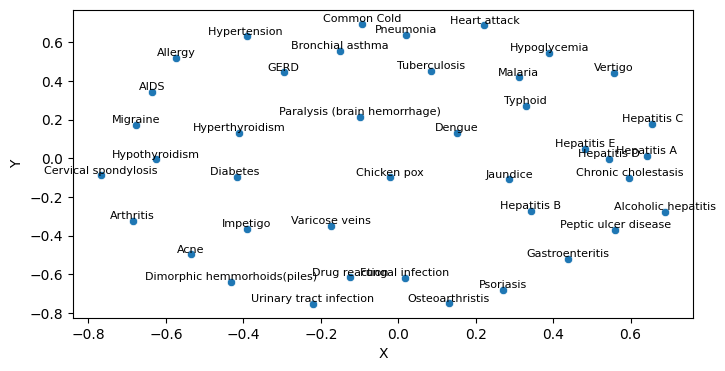

In [40]:
#| fig-align: center
plt.figure(figsize=(8, 4))
ax = sns.scatterplot(
    data=X_transformed_df, x="X", y="Y"
)

for _, r in X_transformed_df.iterrows():
    ax.text(r["X"], r["Y"], r["disease"],
            ha="center", va="bottom", fontsize=8)

:::

To verify if the plot makes intuitive sense, we should inspect the points that
occur nearby to one another. For instance, since we observe Typhoid and Malaria
to be close on the plot, we can retrieve their actual symptoms with:

In [41]:
for x in disease.loc[disease.disease.isin(['Typhoid', 'Malaria']), 'symptom_text'].to_list():
	pprint(x)

'chills,vomiting,nausea,high_fever,diarrhoea,headache,sweating,muscle_pain'
'chills,vomiting,nausea,abdominal_pain,high_fever,fatigue,diarrhoea,headache,constipation,toxic_look_(typhos),belly_pain'


It is important to remember that above, we requested the MDS algorithm to return
us $z$-coordinates in $\mathbf{R}^2$ - two-dimensional Euclidean space, that
replicate the dissimilarity matrix from the higher-dimensional data. This was
for convenience, since the two dimensional plane is easier to plot. One problem
is that, due to information loss, it is possible that in 2D, two points appear
near, but in fact, they may be far apart on a third dimension.

With `plotly`, we can make interactive 3d plots, which can go some way to
alleviating this problem.

::: {.content-visible when-format="pdf"}
::: {.callout-warning}

Stay away from non-interactive 3d plots! For an interaactive version of the 3D
plot, please visit the online version of the textbook.

:::

:::

::: {.content-visible when-format="html"}

::: {#exm-disease-mds-2 style="background-color: #D5D1D164; padding: 20px"}
### Disease symptoms 3D-plot
\index{Disease Symptoms!Description}

Here is the 3-D version of the earlier plot:

In [55]:
#| fig-align: center
embedding3 = MDS(n_components=3, normalized_stress='auto', metric='precomputed',
                 init = 'random', n_init=4,
                 random_state=42, max_iter=500, verbose=0)
X_transformed3 = embedding3.fit_transform(pdist2)

In [51]:
X_transformed3.shape

(41, 3)

In [56]:
X_transformed3_df = pd.DataFrame(X_transformed3, columns=['X', 'Y', 'Z'])
X_transformed3_df['disease'] = disease_names

fig = px.scatter_3d(X_transformed3_df, x='X', y='Y', z='Z', text='disease', 
                     width=900, height=600)
fig.show()

:::

:::

### t-SNE {#sec-03-t-SNE}

t-SNE is an fast, iterative algorithm for *visualising* high-dimensional data.

Once again, suppose we have $N$ *data points* $x_i \in \mathbf{R}^p$. We would
like to choose $N$ *map points* $y_i \in \mathbf{R}^2$ to represent them. Here is 
how the algorithm works:

1. Compute pairwise similarity between the *data points*, using a Gaussian (Normal) kernel.
2. Iteratively update *map points* so that their pairwise similarity is as close as
   possible to the original data points.

The innovation of these algorithm is that the similarity between map points is
computed using a $t$-distribution instead of Gaussian. The $t$-distribution has
fatter tails than the Normal. This ensures that data points that are not close
in $\mathbf{R}^D$ are pushed apart in the map points space.

There are a couple of important parameters in this algorithm.

1. *Perplexity*: This is a parameter that provides a guide on how many neighbours a point has.
   It is recommended to try different values between 5 and 50 and assess if results are 
   meaningful and consistent.
2. *Number of iterations*: This is the number of adjustments to make to the map points before 
   stopping. The difference between map point similarity and data point similarity is 
   measured using Kullback-Leibler Divergence. When this no longer drops quickly, we can
   stop the t-SNE algorithm.

Although you will find t-SNE used in many analyses, you should be aware of
certain caveats when using it. Please take a look at the link in the references
for plots that expound on the following points.

1. t-SNE is for visualisation and exploration, not for clustering.
2. Distances in the map space are not reflective of true distances between datapoints.
3. t-SNE preserves small pairwise distances so that local relationships are preserved.
4. In the map space, distances between clusters (between far-away points) might not mean much (unlike MDS).
5. Make sure you try with different perplexity values, and check that the algorithm has converged.
   
::: {#exm-twitter-tsne-1 style="background-color: #D5D1D164; padding: 20px"}
### Twitter dataset
\index{Twitter!Description}

The [UCI Machine Learning repository](https://archive.ics.uci.edu/dataset/438/health+news+in+twitter)
contains tweets pertaining to health news from more than 15 major news agencies
in 2015. In this example, we are going to encode each BBC tweet in to a
numerical vector of length 384. Then we are going to visualise it using t-SNE.

For more details on how words are converted into vectors, take a look at
@sec-04-numeric-rep-text. In the next code chunk, we use a neural language model
to convert each tweet into the vector of length 384. The model is one of several
models provided and maintained by [Hugging Face](https://huggingface.co/)

In [2]:
import os
hf_token = os.environ.get('HF_TOKEN')

In [4]:
model = SentenceTransformer('sentence-transformers/all-MiniLM-L12-v2')
#sentences = ["This is an example sentence. can we move on?", 
#             "Each sentence is converted"]
#embeddings = model.encode(sentences)
#embeddings.shape

/home/viknesh/NUS/coursesTaught/ind5003-book/env/lib/python3.14/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Now we turn to the dataset of tweets.

In [5]:
bbchealth_df = pd.read_table('data/health+news+in+twitter/Health-Tweets/bbchealth.txt', 
                             delimiter='|', 
			     names=['id', 'datetime', 'tweet'])
bbchealth_tweets = bbchealth_df.tweet
print(bbchealth_tweets[10])

Have GP services got worse? http://bbc.in/1Ci5c22


Above, we have an example of a tweet. We are going to strip off the URL at the
end before encoding each (short) sentence.

In [6]:
t1 = bbchealth_tweets.str.replace(' http.*$', '', regex=True)
t2 = t1.str.replace('^VIDEO:', '', regex=True)
t2_l = t2.to_list()

embeddings = model.encode(t2_l)

:::

<br>

::: {#exm-twitter-tsne-2 style="background-color: #D5D1D164; padding: 20px"}
### Twitter dataset t-SNE output
\index{Twitter!t-SNE Output}

The following code generates an interactive plot based on the t-SNE visualisation.

In [7]:
tsne1 = TSNE(n_components=2, init="random", perplexity=10, verbose=1, 
             random_state=43, max_iter=5000)
X_transformed2 = tsne1.fit_transform(embeddings)

df2 = pd.DataFrame(X_transformed2, columns=['x','y'])
df2['labels'] = t2_l

[t-SNE] Computing 31 nearest neighbors...
[t-SNE] Indexed 3929 samples in 0.001s...
[t-SNE] Computed neighbors for 3929 samples in 0.246s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3929
[t-SNE] Computed conditional probabilities for sample 2000 / 3929
[t-SNE] Computed conditional probabilities for sample 3000 / 3929
[t-SNE] Computed conditional probabilities for sample 3929 / 3929
[t-SNE] Mean sigma: 0.272988
[t-SNE] KL divergence after 250 iterations with early exaggeration: 95.560860
[t-SNE] KL divergence after 5000 iterations: 1.726707


::: {.content-visible when-format="pdf"}

Please refer to the online version of the text for an interactive plot.

<Axes: xlabel='x', ylabel='y'>

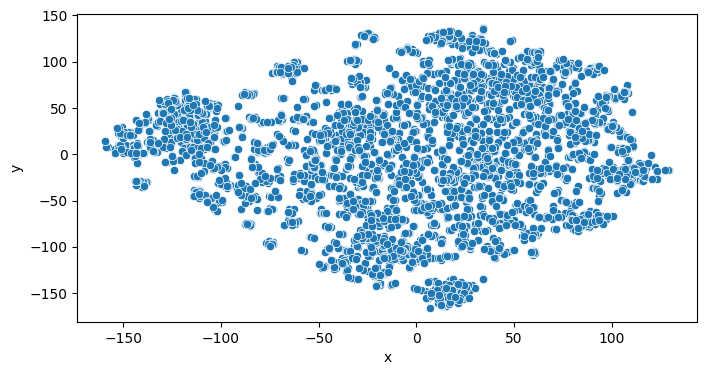

In [8]:
#| fig-align: center
plt.figure(figsize=(8, 4))
sns.scatterplot( data=df2, x="x", y="y")

:::


::: {.content-visible when-format="html"}

This plot is only visible in the HTML version of the textbook.

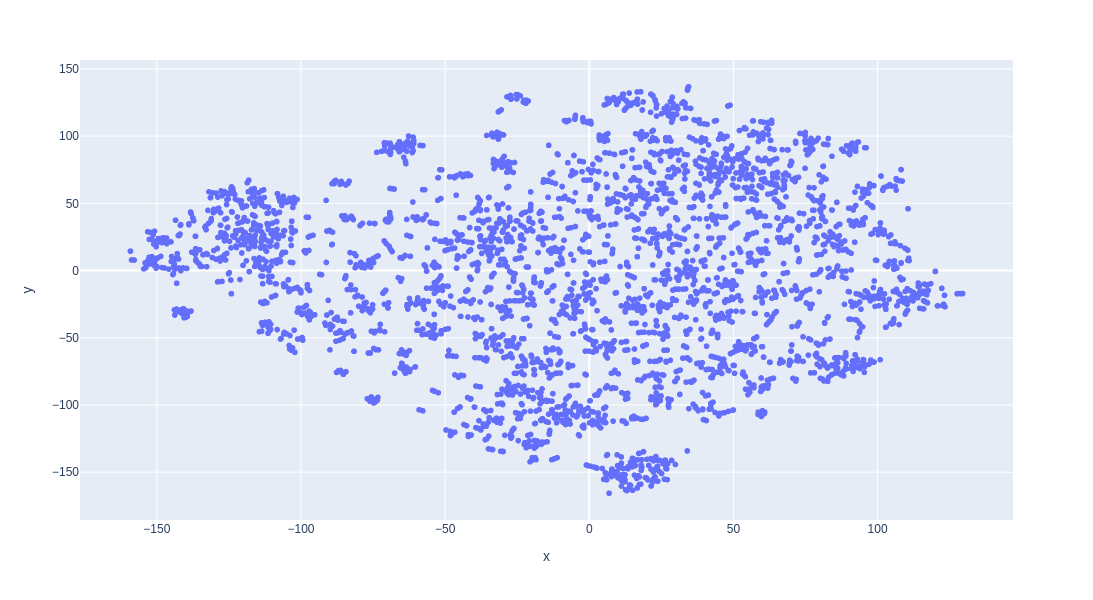

In [9]:
#| fig-align: center

fig = px.scatter(df2, x='x', y='y', hover_name='labels',
                 width=900, height=600)
fig.show()

:::

:::

For another application of t-SNE visualisation, refer to @sec-04-t-SNE.

## References

### Website references
1. [Clustering performance evaluation](https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation) There are many
   other ways of assessing what the optimal number of clusters should be.
3. [More information on isolation forests](https://cran.r-project.org/web/packages/isotree/vignettes/An_Introduction_to_Isolation_Forests.html)
4. [Wikipedia entry on Jaccard Similarity (or index)](https://en.wikipedia.org/wiki/Jaccard_index): This page introduces variants of the index,
   which may be relevant when one has *counts* of the number of times each item appears in the set.
6. [Caveats when using t-SNE](https://distill.pub/2016/misread-tsne/)
7. [DataCamp on t-SNE](https://www.datacamp.com/tutorial/introduction-t-sne): This tutorial consists of a worked-through example on a churn dataset. It
   includes a comparison with PCA.

### Video references

1. [t-SNE, explained by Josh Starmer](https://www.youtube.com/watch?v=NEaUSP4YerM)
2. [A general video on high-dimensional space](https://www.youtube.com/watch?v=wvsE8jm1GzE): A nice explainer from Google.
